# LNR.TO - multivariate conventional-methods comparison

A stock-specific version of the financial-markets reference notebook for Linamar Corporation (`LNR.TO`). It compares conventional forecasting methods on leak-safe cumulative log returns at 1, 5, and 21 business-day horizons.

All methods read the same target and optional lagged Yahoo Finance covariate panel: VIX, WTI, NASDAQ, gold, and the U.S. dollar index. The target-only and covariate variants make it possible to measure whether the panel improves forecasts for an industrial stock.

The default `lnr_smoke.yaml` window is deliberately short. Use a longer spec or edit the experiment configuration below when you are ready for a broader comparison. These are statistical return forecasts, not investment advice.

## Forecast targets and cutoff discipline

The targets are adjusted-close cumulative log returns, not the share-price level:

- `lnr_logret_1b`: next-session return
- `lnr_logret_5b`: forward one-week return
- `lnr_logret_21b`: forward one-month return

The LNR data service lags every covariate by one business day before registration. Numerical predictors receive only observations available at the forecast origin through `ForecastContext`, so the comparison is cutoff-aware.

---
## 1. Setup

Warm the Yahoo Finance cache before running: `PYTHONPATH=aieng-forecasting:implementations python implementations/LNR_Forecasting/run_lnr_forecast.py`. Set `REFRESH_CACHE = True` below to fetch fresh data.

In [2]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "aieng-forecasting").is_dir():
            return candidate
    return here

ROOT = _repo_root()
sys.path[:0] = [str(ROOT / "aieng-forecasting"), str(ROOT / "implementations")]
load_dotenv(ROOT / ".env", override=False)

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    cached_multi_backtest,
    describe_spec,
)
from aieng.forecasting.methods import (
    DartsAutoARIMAPredictor,
    DartsExponentialSmoothingPredictor,
    DartsKalmanForecasterPredictor,
    DartsLightGBMPredictor,
    DartsLinearRegressionPredictor,
    LastValuePredictor,
)
from LNR_Forecasting import DEFAULT_COVARIATE_SERIES_IDS, build_lnr_multivariate_service
from LNR_Forecasting.data import lnr_logret_series_id
from sp500_forecasting.leaderboard import build_leaderboard, build_return_compare_frame

SPECS_DIR = ROOT / "implementations" / "LNR_Forecasting" / "specs"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
DATA_HISTORY_START = "2015-01-01"
REFRESH_CACHE = False

svc = build_lnr_multivariate_service(
    windows=(1, 5, 21),
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    refresh=REFRESH_CACHE,
)
registered = set(svc.series_ids)
COVARIATES = [series_id for series_id in DEFAULT_COVARIATE_SERIES_IDS if series_id in registered]
print("targets:", sorted(series_id for series_id in registered if series_id.startswith("lnr_logret_")))
print(f"covariates registered: {len(COVARIATES)} / {len(DEFAULT_COVARIATE_SERIES_IDS)} requested")

targets: ['lnr_logret_1b', 'lnr_logret_21b', 'lnr_logret_5b']
covariates registered: 5 / 5 requested


---
## 2. Configuration

The YAML spec defines the experiment window and tasks. Predictor choices and hyperparameters stay in this notebook.

In [3]:
EXPERIMENT_CONFIG = "smoke"
_SPEC_FILES = {"smoke": "lnr_smoke.yaml"}
with (SPECS_DIR / _SPEC_FILES[EXPERIMENT_CONFIG]).open() as spec_file:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(spec_file))
print(f"Config: {EXPERIMENT_CONFIG!r} -> {_SPEC_FILES[EXPERIMENT_CONFIG]}")
print(describe_spec(backtest_spec, data_service=svc))

Config: 'smoke' -> lnr_smoke.yaml
MultiTargetBacktestSpec (spec_id=lnr_smoke)
  description: Smoke comparison for Linamar Corporation adjusted-close cumulative log returns at 1, 5, and 21 business-day horizons.
  start:       2025-10-06 00:00:00
  end:         2025-11-14 00:00:00
  stride:      5
  warmup:      250
  tasks:       3

Task: lnr_logret_1b
  description: LNR.TO next-session adjusted-close log return.
  horizons:    1
  frequency:   B
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: lnr_logret_1b
    description:    LNR.TO adjusted-close cumulative log return over 1 business day(s) (next-session)
    source:         Yahoo Finance (LNR.TO), derived
    units:          log-return
    frequency:      B

Task: lnr_logret_5b
  description: LNR.TO forward one-week adjusted-close log return.
  horizons:    5
  frequency:   B
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: lnr_log

---
## 3. Target context - observed LNR returns

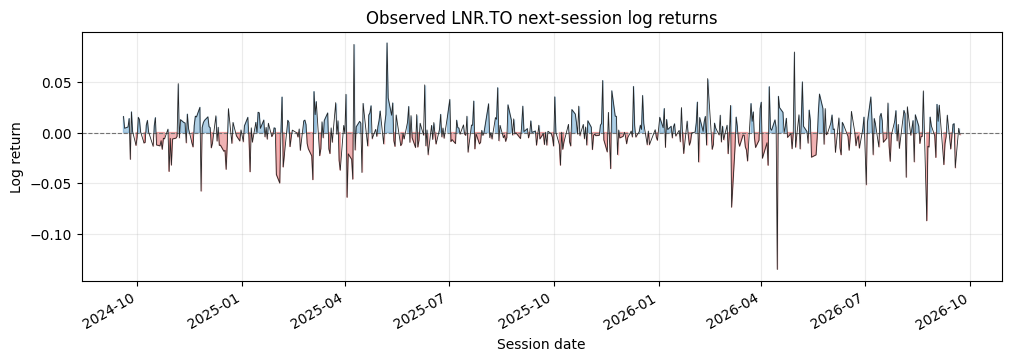

In [6]:
from datetime import datetime, timezone

as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)
target_frame = svc.get_series(lnr_logret_series_id(1), as_of=as_of)
target_frame["timestamp"] = pd.to_datetime(target_frame["timestamp"])
target_frame = target_frame.tail(504)
fig, ax = plt.subplots(figsize=(10, 3.5), layout="constrained")
ax.axhline(0.0, color="0.45", linewidth=0.8, linestyle="--")
ax.fill_between(target_frame["timestamp"], 0.0, target_frame["value"], where=target_frame["value"] >= 0, alpha=0.35, color="#1f77b4")
ax.fill_between(target_frame["timestamp"], 0.0, target_frame["value"], where=target_frame["value"] < 0, alpha=0.35, color="#d62728")
ax.plot(target_frame["timestamp"], target_frame["value"], color="0.15", linewidth=0.6)
ax.set(title="Observed LNR.TO next-session log returns", xlabel="Session date", ylabel="Log return")
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
plt.show()

---
## 4. Predictors - target-only versus covariate panel

The roster includes a naive floor, classical univariate methods, and target-only/covariate variants of the two regression methods. AutoARIMA is included for completeness but can be commented out when iterating quickly.

In [7]:
LAGS = 5
NUM_SAMPLES = 100
LGBM_KWARGS = {"num_threads": 1, "n_jobs": 1, "verbosity": -1}

naive = LastValuePredictor()
ets = DartsExponentialSmoothingPredictor(num_samples=NUM_SAMPLES)
kalman = DartsKalmanForecasterPredictor(num_samples=NUM_SAMPLES)
autoarima = DartsAutoARIMAPredictor(num_samples=NUM_SAMPLES)
linreg = DartsLinearRegressionPredictor(lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES)
linreg_cov = DartsLinearRegressionPredictor(lags=LAGS, lags_past_covariates=LAGS, covariate_series_ids=COVARIATES, num_samples=NUM_SAMPLES)
lightgbm = DartsLightGBMPredictor(lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES, lgbm_kwargs=LGBM_KWARGS)
lightgbm_cov = DartsLightGBMPredictor(lags=LAGS, lags_past_covariates=LAGS, covariate_series_ids=COVARIATES, num_samples=NUM_SAMPLES, lgbm_kwargs=LGBM_KWARGS)
all_predictors = [naive, ets, kalman, autoarima, linreg, linreg_cov, lightgbm, lightgbm_cov]
PREDICTOR_COVARIATES = {linreg_cov.predictor_id: COVARIATES, lightgbm_cov.predictor_id: COVARIATES}
PREDICTOR_LABELS = {
    naive.predictor_id: "Naive", ets.predictor_id: "ETS", kalman.predictor_id: "Kalman",
    autoarima.predictor_id: "AutoARIMA", linreg.predictor_id: "LinReg",
    linreg_cov.predictor_id: "LinReg + cov", lightgbm.predictor_id: "LightGBM",
    lightgbm_cov.predictor_id: "LightGBM + cov",
}
print(f"{len(all_predictors)} predictors configured:")
for predictor in all_predictors:
    print(" ", predictor.predictor_id)

8 predictors configured:
  last_value_naive
  darts_ets
  darts_kalman
  darts_autoarima
  darts_linreg
  darts_linreg_cov
  darts_lightgbm
  darts_lightgbm_cov


---
## 5. Backtest - the comparison

Results are cached under `data/predictions/<spec_id>/`. Re-running the cell reuses completed forecasts.

In [8]:
results_by_predictor = {}
for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor, spec=backtest_spec, data_service=svc, store_dir=PREDICTIONS_DIR
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:18s} mean CRPS = {result.mean_score:.5f} ({len(result.predictions)} preds)")
RESULTS_DF = build_leaderboard(
    results_by_predictor, svc, covariates_by_predictor=PREDICTOR_COVARIATES, labels_by_predictor=PREDICTOR_LABELS
)
display(RESULTS_DF.style.format({"mean_crps": "{:.5f}", "dir_accuracy": "{:.3f}"}, na_rep="-"))

Running last_value_naive ...
  lnr_logret_1b      mean CRPS = 0.01544 (6 preds)
  lnr_logret_5b      mean CRPS = 0.04878 (5 preds)
  lnr_logret_21b     mean CRPS = 0.06284 (6 preds)
Running darts_ets ...
  lnr_logret_1b      mean CRPS = 0.00944 (6 preds)
  lnr_logret_5b      mean CRPS = 0.03491 (5 preds)
  lnr_logret_21b     mean CRPS = 0.05775 (6 preds)
Running darts_kalman ...
  lnr_logret_1b      mean CRPS = 0.00957 (6 preds)
  lnr_logret_5b      mean CRPS = 0.01900 (5 preds)
  lnr_logret_21b     mean CRPS = 0.03996 (6 preds)
Running darts_autoarima ...
  lnr_logret_1b      mean CRPS = 0.01033 (6 preds)
  lnr_logret_5b      mean CRPS = 0.01978 (5 preds)
  lnr_logret_21b     mean CRPS = 0.03696 (6 preds)
Running darts_linreg ...
  lnr_logret_1b      mean CRPS = 0.00904 (6 preds)
  lnr_logret_5b      mean CRPS = 0.02054 (5 preds)
  lnr_logret_21b     mean CRPS = 0.03367 (6 preds)
Running darts_linreg_cov ...
  lnr_logret_1b      mean CRPS = 0.00975 (6 preds)
  lnr_logret_5b      mean 

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval
0,1,lnr_logret_1b,LightGBM,False,0,—,darts_lightgbm,0.00868,6,6,0,0.500000,0.333333,0.400000,0.500,0.777778,6
1,1,lnr_logret_1b,LinReg,False,0,—,darts_linreg,0.00904,6,6,0,0.500000,0.333333,0.400000,0.500,0.444444,6
2,1,lnr_logret_1b,ETS,False,0,—,darts_ets,0.00944,6,6,0,0.666667,0.666667,0.666667,0.667,0.666667,6
3,1,lnr_logret_1b,Kalman,False,0,—,darts_kalman,0.00957,6,6,0,0.666667,0.666667,0.666667,0.667,0.555556,6
4,1,lnr_logret_1b,LinReg + cov,True,5,"vix_level_l1b, oil_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b, gold_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b",darts_linreg_cov,0.00975,6,6,0,0.333333,0.333333,0.333333,0.333,0.111111,6
5,1,lnr_logret_1b,LightGBM + cov,True,5,"vix_level_l1b, oil_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b, gold_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b",darts_lightgbm_cov,0.01004,6,6,0,0.333333,0.333333,0.333333,0.333,0.111111,6
6,1,lnr_logret_1b,AutoARIMA,False,0,—,darts_autoarima,0.01033,6,6,0,0.250000,0.333333,0.285714,0.167,0.111111,6
7,1,lnr_logret_1b,Naive,False,0,—,last_value_naive,0.01544,6,6,0,0.333333,0.333333,0.333333,0.333,0.333333,6
8,5,lnr_logret_5b,LightGBM + cov,True,5,"vix_level_l1b, oil_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b, gold_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b",darts_lightgbm_cov,0.01503,5,5,1,1.000000,1.000000,1.000000,1.000,1.000000,5
9,5,lnr_logret_5b,Kalman,False,0,—,darts_kalman,0.01900,5,5,1,1.000000,0.500000,0.666667,0.600,0.500000,5


### Mean CRPS by horizon

Lower CRPS is better. Direction accuracy is aligned to each horizon's realised return and is most useful as a directional diagnostic at the shorter horizons.

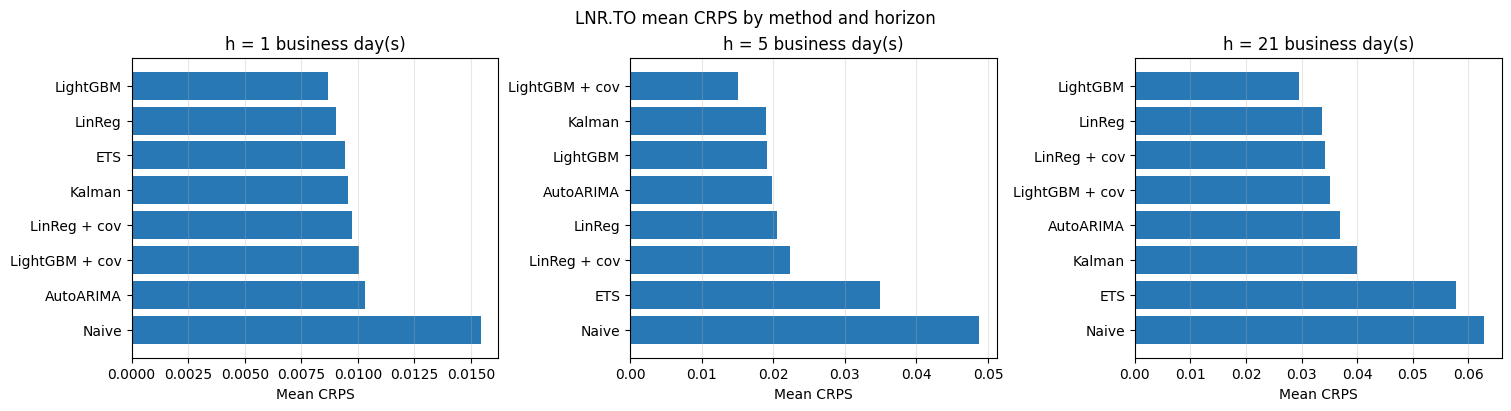

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained", squeeze=False)
for ax, horizon in zip(axes[0], sorted(RESULTS_DF["horizon"].unique())):
    frame = RESULTS_DF[RESULTS_DF["horizon"] == horizon].sort_values("mean_crps")
    ax.barh(frame["model"], frame["mean_crps"], color="#2878b5")
    ax.invert_yaxis()
    ax.set_title(f"h = {horizon} business day(s)")
    ax.set_xlabel("Mean CRPS")
    ax.grid(True, axis="x", alpha=0.3)
fig.suptitle("LNR.TO mean CRPS by method and horizon")
plt.show()

---
## 6. Forecast versus realised (next session)

This reuses cached `h=1` predictions and renders the forecast median against the realised LNR return.

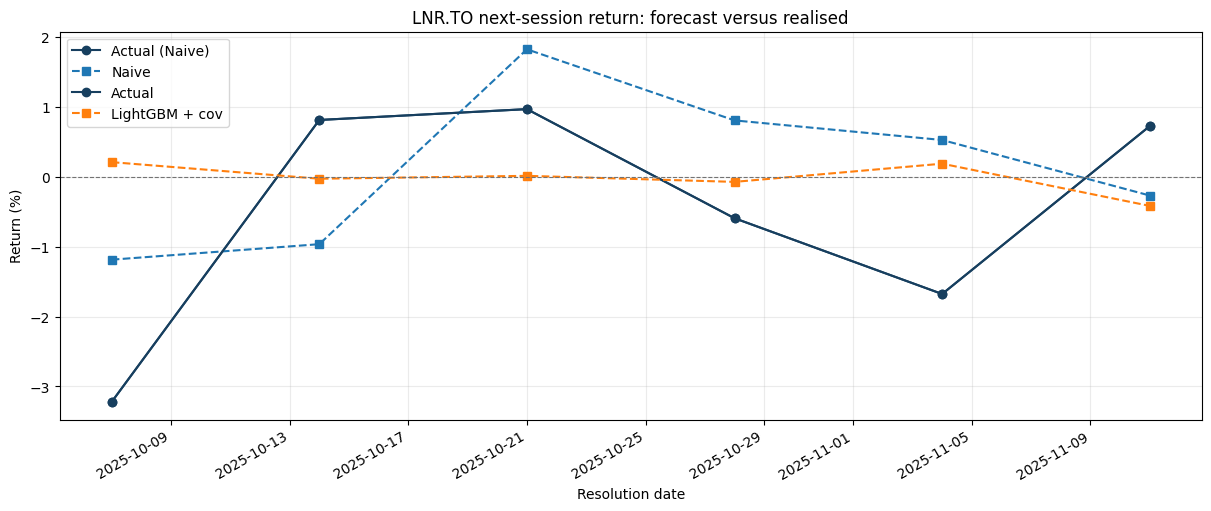

In [10]:
h1_task = "lnr_logret_1b"
demo_ids = [naive.predictor_id, lightgbm_cov.predictor_id]
compare_by_run = {}
for predictor_id in demo_ids:
    result = results_by_predictor.get(predictor_id, {}).get(h1_task)
    if result is not None:
        compare_by_run[PREDICTOR_LABELS[predictor_id]] = build_return_compare_frame(result.predictions, svc, h1_task)

fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")
for label, frame in compare_by_run.items():
    frame = frame.sort_values("session")
    ax.plot(frame["session"], 100 * frame["actual_return"], color="#173f5f", marker="o", label=f"Actual ({label})" if label == next(iter(compare_by_run)) else "Actual")
    ax.plot(frame["session"], 100 * frame["forecast_return"], linestyle="--", marker="s", label=label)
ax.axhline(0, color="0.45", linewidth=0.8, linestyle="--")
ax.set(title="LNR.TO next-session return: forecast versus realised", xlabel="Resolution date", ylabel="Return (%)")
ax.grid(True, alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.show()

## Where to go next

- Add longer LNR specs for a 2025 comparison and a protected held-out period.
- Tune `LAGS`, sample counts, and the predictor roster in Section 4.
- Compare the target-only and `+ cov` rows at each horizon.
- Add an LNR-specific LLM-Process or agentic predictor only after defining a post-training-cutoff evaluation window.

The covariate data remains market context, not a proxy for Linamar fundamentals. For company-specific signals, extend the data service with a documented, release-timestamped source before adding it to the panel.